# Linear Regression

## Introduction and fancy algebra

Where:
- $y$ is the dependent variable
- $a$ is the y-intercept, the value of $y$ when $x = 0$
- $bx_1$ etc. are the fearues

$y = a + bx_1 + cx_2 + ... + mx_m$

If we have multiple data points: for any data point $i$ in the dataset, $y_i$ is the dependent variable, $x_{i,1}$ to $x_{i,m}$ the features, and $a$ is the y-intercept.

We solve for parameters $a$ to $m$.

$\begin{equation*}
\begin{matrix}
y_1 \\ y_2 \\
\vdots \\ y_n
\end{matrix} \qquad
\begin{bmatrix}
a &+ & bx_{1,1} &+ & cx_{1,2} & \ldots &+ & mx_{1,m} \\
a &+ & bx_{2,1} &+ & cx_{2,2} & \ldots &+ & mx_{2,m} \\
\vdots & \ & \vdots & \ & \vdots & \ & \ & \vdots\\
a & + &bx_{n,1} & + & cx_{n,2} & \ldots & + & mx_{n,m}
\end{bmatrix}
\end{equation*}$

In matrix form:

$\begin{bmatrix}y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}$ = $\begin{bmatrix}1 & x_{1,1} & x_{1,2} & \ldots & x_{1,m} \\ 1 & x_{2,1} & x_{2,2} & \ldots & x_{2,m} \\ \vdots & \vdots & \vdots & \ & \vdots \\ 1 & x_{n,1} & x_{n,2} & \ldots & x_{n,m} \end{bmatrix}$ $\begin{bmatrix}a \\ b \\ c \\ \vdots \\ m \end{bmatrix}$



## Simple Linear Regression

Consider fitting a line to points on a Cartesian plane (2-D surface, with $y$-axis perpendicular to horizontal $x$-axis). To fit such a line, the only parameters we require are a $y$-intercept (say, $\beta_0$) and a slope (say, $\beta_1$). The line is represented by the equation:

$$y = \beta_0 + \beta_1 x$$

This corresponds to the case where we have a single feature (a single predictor variable,
$x$) in a regression model, where $\epsilon$ denotes error.

$$y = \beta_0 + \beta_1 x + \epsilon$$

In an ideal case where the error term is zero, $\beta_0$ represents the value of the dependent variable $y$ at $x = 0$. Within the range of the independent variable $x$, $\beta_1$ represents the increase in the outcome $y$ corresponding to a unit change in $x$.

In more technical terms: for any given instance $i$, $\epsilon_i$ is a measure of the difference between the true value of $y_i$ and the predicted value of $\hat{y}_i$. If the model predicts $y_i$ perfectly, then $\epsilon_i = 0$.

In the case of a model with a single predictor $x$, we can use this formula to estimate $\beta_1$:

$$\hat{\beta}_1 = \frac{\text{cov}(x,y)}{\sigma^2_x}$$



#### Examples - Linear Regression

##### Example 1 - Linear Regression

In [79]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

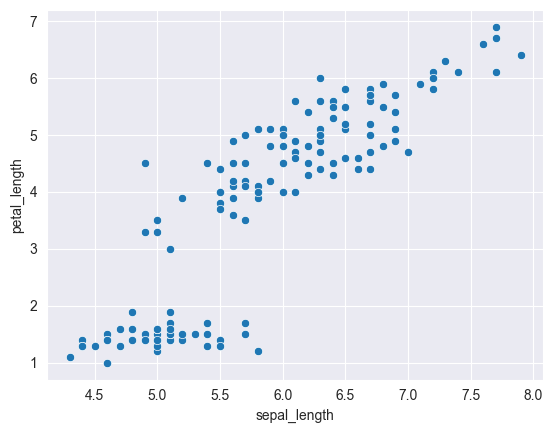

In [80]:
iris = sns.load_dataset('iris')
x = iris.sepal_length
y = iris.petal_length
_ = sns.scatterplot(x=x, y=y)

In [81]:
n = iris.sepal_width.size
xbar, ybar = x.mean(), y.mean()
product = []
for i in range(n):
    product.append((x[i]-xbar)*(y[i]-ybar))
cov = sum(product)/n

In [82]:
beta1 = cov/np.var(x)
beta1

np.float64(1.8584329782548417)

With the slope $\beta_1$ estimated, we can now estimate the intercept $\beta_0$ using the formula:

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

In [83]:
beta0 = ybar - beta1*xbar
beta0

np.float64(-7.101443369602459)

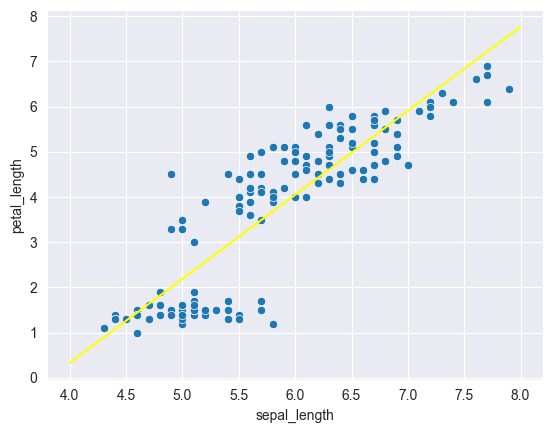

In [84]:
xline = np.linspace(4, 8, 1000)
yline = beta0 + beta1*xline
sns.scatterplot(x=x, y=y)
_ = plt.plot(xline, yline, color='yellow')

In regression modeel terms, if we were provided with a sepal length $x_i$, we could use the parameter estimates $\hat{\beta}_0$ and $\hat{\beta}_1$ to predict the petal length of an iris flower, $\hat{y}_i$:

$$\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_i$$

Let's calculate the predicted petal length for a sepal length of 5.5 cm.

In [85]:
x_i = 5.5

In [86]:
y_i = beta0 + beta1 * x_i
y_i

np.float64(3.1199380107991708)

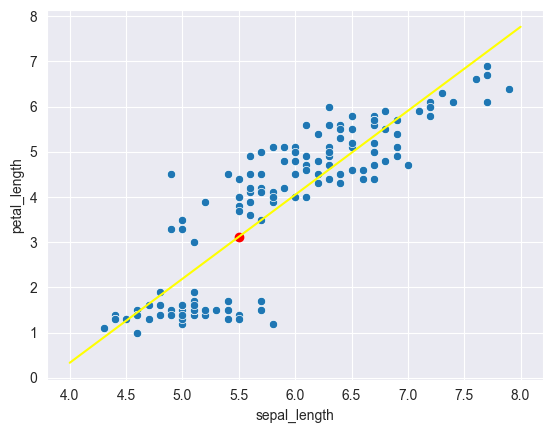

In [87]:
sns.scatterplot(x=x, y=y)
plt.plot(xline, yline, color='yellow')
_ = plt.scatter(x_i, y_i, marker='o', color='red')

##### Example 2 - Linear Regression

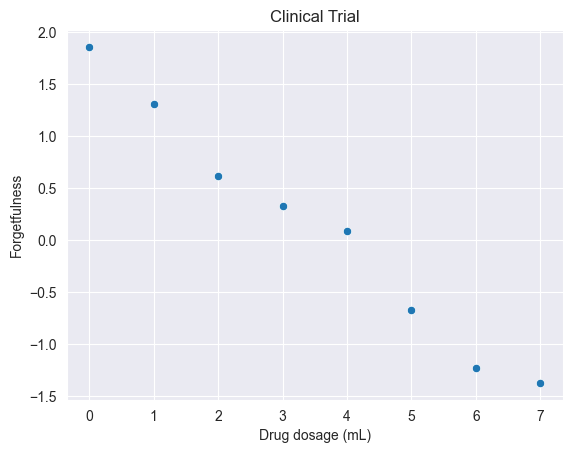

In [88]:
x = np.array([0, 1, 2, 3, 4, 5, 6, 7.])
y = np.array([1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37])
sns.scatterplot(x=x, y=y)
plt.title("Clinical Trial")
plt.xlabel("Drug dosage (mL)")
_ = plt.ylabel("Forgetfulness")

In [89]:
cov_mat = np.cov(x, y)
beta1 = cov_mat[0,1]/cov_mat[0,0]
beta0 = y.mean() - beta1*x.mean()
xline = np.linspace(0, 7, 1000)
yline = beta0 + beta1*xline

Let's assume that the drug dosage is 4.5ml. We can use the parameter estimates $\hat{\beta}_0$ and $\hat{\beta}_1$ to predict the forgetfulness level of a patient.

In [90]:
x_i = 4.5
y_i = beta0 + beta1*x_i
y_i

np.float64(-0.35178571428571437)

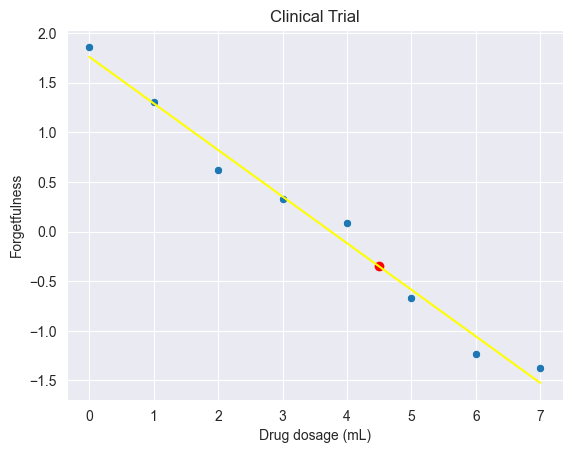

In [91]:
sns.scatterplot(x=x, y=y)
plt.title("Clinical Trial")
plt.xlabel("Drug dosage (mL)")
plt.ylabel("Forgetfulness")
plt.plot(xline, yline, color='yellow')
_ = plt.scatter(x_i, y_i, marker='o', color='red')

#### Example 3 - Linear Regression

<Axes: >

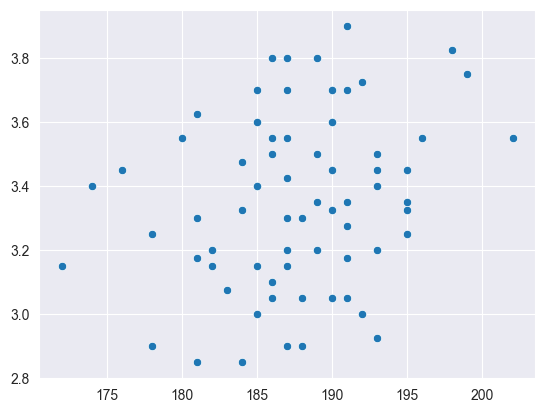

In [92]:
penguins = sns.load_dataset('penguins').dropna()
adelie = penguins[penguins.species == 'Adelie']
x = adelie[adelie.sex == 'Female']['flipper_length_mm'].to_numpy()
y = adelie[adelie.sex == 'Female']['body_mass_g'].to_numpy()/1000
sns.scatterplot(x=x, y=y)

In [93]:
cov_mat = np.cov(x, y)
beta1 = cov_mat[0,1]/cov_mat[0,0]
beta0 = y.mean() - beta1*x.mean()
cov_mat, beta1, beta0

(array([[31.304414  ,  0.3962852 ],
        [ 0.3962852 ,  0.07256564]]),
 np.float64(0.012659083726357767),
 np.float64(0.9915290574707036))

In [94]:
x_i = 197
y_i = beta0 + beta1*x_i
y_i

np.float64(3.485368551563184)

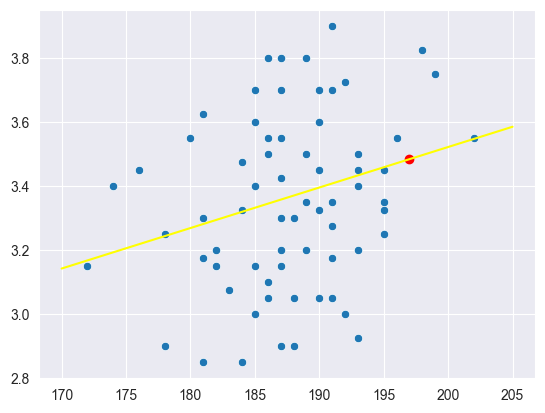

In [95]:
xline = np.linspace(170, 205, 1000)
yline = beta0 + beta1*xline
sns.scatterplot(x=x, y=y)
plt.plot(xline, yline, color='yellow')
_ = plt.scatter(x_i, y_i, marker='o', color='red')

#### Example 4 - Training a linear regression model

In [98]:
dataset = pd.read_csv('data/salary_data.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [99]:
# splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

In [100]:
# Training the model on the training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [101]:
y_pred = regressor.predict(X_test)

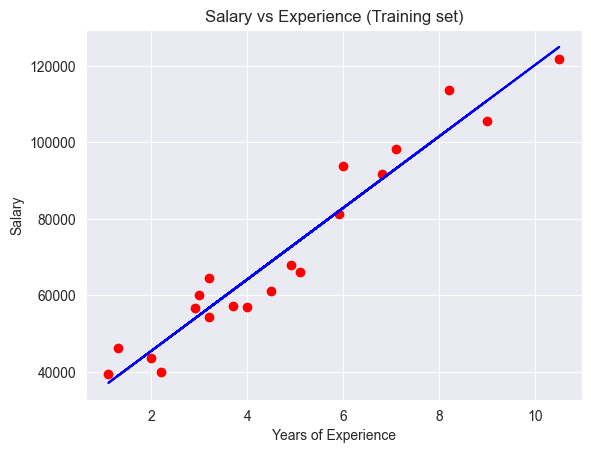

In [102]:
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

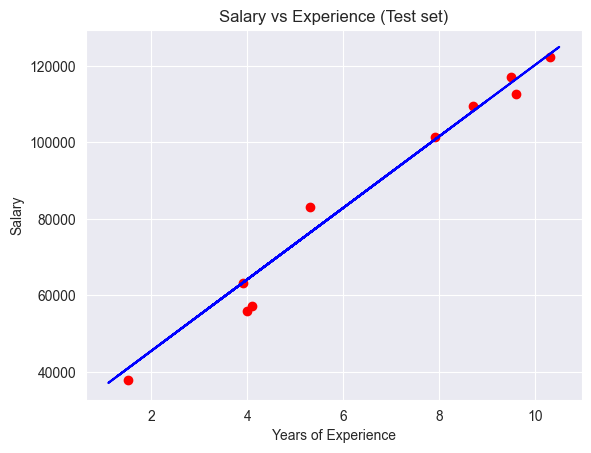

In [103]:
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()